# Gold-link extraction sanity — Week 2

Three things in one notebook:

1. **Overview** of the four canonical gold-link files materialised under `data/processed/`.
2. **Cross-validation** of sqlglot's Tier-1 against Taniguchi's human Tier-1 on dev (counts, P/R/F1, disagreement examples, Tier-1 vs Tier-2 gap, per-hardness breakdown).
3. **Worked examples** on `concert_singer` — the side-by-side figure that lands in the methodology chapter.

In [1]:
import json
import logging
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, "src")

logging.basicConfig(level=logging.ERROR)  # silence per-row warnings; keep ERROR+

import pandas as pd
import matplotlib.pyplot as plt

from schema_linking.data_loader import load_spider_questions
from schema_linking.schema_parser import load_schemas
from schema_linking.taniguchi_loader import load_taniguchi_annotations, to_gold_links
from schema_linking.gold_link_extractor import extract_tier1_all, extract_tier2_all
from schema_linking.utils.difficulty import eval_hardness

dev = load_spider_questions("dev")
schemas = load_schemas()
taniguchi_raw = load_taniguchi_annotations()
taniguchi = to_gold_links(taniguchi_raw, dev, schemas)
tier1 = extract_tier1_all(dev, schemas)
tier2 = extract_tier2_all(dev, schemas)

print(f"dev: {len(dev)}, taniguchi: {len(taniguchi)}, sqlglot tier1: {len(tier1)}, sqlglot tier2: {len(tier2)}")

dev: 1034, taniguchi: 1034, sqlglot tier1: 1034, sqlglot tier2: 1034


## 0. Canonical gold-link files

Both splits × both tiers, materialised under `data/processed/`. Dev Tier-1 comes from the Taniguchi human annotation; the other three are sqlglot-derived from the gold SQL. See `docs/decisions.md` for the rationale (sqlglot is the only option on train — Taniguchi never annotated train).

In [2]:
FILES = [
    ("data/processed/gold_links_dev_mentioned.json",   "dev",   1, "Taniguchi (human)"),
    ("data/processed/gold_links_dev_all_sql.json",     "dev",   2, "sqlglot"),
    ("data/processed/gold_links_train_mentioned.json", "train", 1, "sqlglot"),
    ("data/processed/gold_links_train_all_sql.json",   "train", 2, "sqlglot"),
]

rows = []
for path, split, tier, source in FILES:
    p = Path(path)
    raw = json.loads(p.read_text(encoding="utf-8"))
    n_tables = sum(len(v["tables"]) for v in raw.values())
    n_columns = sum(len(v["columns"]) for v in raw.values())
    rows.append({
        "path": path,
        "split": split,
        "tier": tier,
        "source": source,
        "size_KB": round(p.stat().st_size / 1024, 1),
        "queries": len(raw),
        "mean_tables": round(n_tables / len(raw), 2),
        "mean_columns": round(n_columns / len(raw), 2),
    })
files_df = pd.DataFrame(rows)
files_df

,path,split,tier,source,size_KB,queries,mean_tables,mean_columns
0,data/processed/gold_links_dev_mentioned.json,dev,1,Taniguchi (human),215.9,1034,1.46,1.71
1,data/processed/gold_links_dev_all_sql.json,dev,2,sqlglot,274.6,1034,1.51,2.72
2,data/processed/gold_links_train_mentioned.json,train,1,sqlglot,1566.0,7000,1.38,1.98
3,data/processed/gold_links_train_all_sql.json,train,2,sqlglot,1949.5,7000,1.55,2.88


In [3]:
# JSON shape sample — one entry, copy-pasteable
sample = json.loads(Path("data/processed/gold_links_dev_mentioned.json").read_text(encoding="utf-8"))
first_key = next(iter(sample))
print(f"key (Spider qid): {first_key!r}")
print(json.dumps(sample[first_key], indent=2))

key (Spider qid): '0'
{
  "db_id": "concert_singer",
  "tables": [
    "singer"
  ],
  "columns": []
}


## 1. Counts

Mean tables and columns per query for each gold source on **dev**.

In [4]:
def counts_frame(name, gold):
    return pd.Series({
        "queries": len(gold),
        "mean_tables": sum(len(g.tables) for g in gold.values()) / len(gold),
        "mean_columns": sum(len(g.columns) for g in gold.values()) / len(gold),
        "total_table_links": sum(len(g.tables) for g in gold.values()),
        "total_column_links": sum(len(g.columns) for g in gold.values()),
    }, name=name)

counts_df = pd.concat([
    counts_frame("taniguchi_tier1", taniguchi),
    counts_frame("sqlglot_tier1",   tier1),
    counts_frame("sqlglot_tier2",   tier2),
], axis=1).T.round(3)
counts_df

,queries,mean_tables,mean_columns,total_table_links,total_column_links
taniguchi_tier1,1034.0,1.460,1.709,1510.0,1767.0
sqlglot_tier1,1034.0,1.324,1.921,1369.0,1986.0
sqlglot_tier2,1034.0,1.514,2.717,1565.0,2809.0


## 2. Agreement — Taniguchi as ground truth

Micro-averaged precision / recall / F1, plus per-query SRR (predicted ⊇ gold), separately for tables and columns.

In [5]:
def micro_metrics(gold_dict, pred_dict, key_fn):
    tp = fp = fn = 0
    srr_hits = 0
    for qid, g in gold_dict.items():
        p = pred_dict.get(qid)
        if p is None:
            continue
        g_set, p_set = set(key_fn(g)), set(key_fn(p))
        tp += len(g_set & p_set)
        fp += len(p_set - g_set)
        fn += len(g_set - p_set)
        if g_set.issubset(p_set):
            srr_hits += 1
    prec = tp / (tp + fp) if (tp + fp) else 1.0
    rec  = tp / (tp + fn) if (tp + fn) else 1.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return {"precision": prec, "recall": rec, "f1": f1,
            "srr": srr_hits / len(gold_dict),
            "tp": tp, "fp": fp, "fn": fn}

rows = []
for pred_name, pred_dict in [("sqlglot_tier1", tier1), ("sqlglot_tier2", tier2)]:
    for level, key_fn in [("tables", lambda g: g.tables), ("columns", lambda g: g.columns)]:
        m = micro_metrics(taniguchi, pred_dict, key_fn)
        rows.append({"prediction": pred_name, "level": level, **m})

agreement_df = pd.DataFrame(rows)[["prediction", "level", "precision", "recall", "f1", "srr", "tp", "fp", "fn"]]
agreement_df.round(4)

,prediction,level,precision,recall,f1,srr,tp,fp,fn
0,sqlglot_tier1,tables,0.9613,0.8715,0.9142,0.8240,1316,53,194
1,sqlglot_tier1,columns,0.8414,0.9457,0.8905,0.9159,1671,315,96
2,sqlglot_tier2,tables,0.9438,0.9781,0.9607,0.9681,1477,88,33
3,sqlglot_tier2,columns,0.6084,0.9672,0.7469,0.9468,1709,1100,58


In [6]:
out_path = Path("outputs/results/tier1_validation.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
agreement_df.round(6).to_csv(out_path, index=False)
print(f"wrote {out_path}")

wrote outputs/results/tier1_validation.csv


## 3. Disagreement examples

Ten dev queries where sqlglot Tier-1 differs from Taniguchi at table or column level. The dominant pattern: Taniguchi annotates both join sides as Tier-1 when the question semantically references both entities, while strict-Tier-1 drops the side whose only column references in the gold SQL live inside `JOIN ON`.

In [7]:
def diff_summary(qid):
    g, p = taniguchi[qid], tier1[qid]
    return {
        "missing_tables":  set(g.tables)  - set(p.tables),
        "extra_tables":    set(p.tables)  - set(g.tables),
        "missing_columns": set(g.columns) - set(p.columns),
        "extra_columns":   set(p.columns) - set(g.columns),
    }

disagreements = [qid for qid in taniguchi if any(diff_summary(qid).values())]
print(f"queries with any disagreement: {len(disagreements)} / {len(taniguchi)}\n")

for qid in disagreements[:10]:
    ex = dev[qid]
    d = diff_summary(qid)
    print(f"qid={qid}  db={ex.db_id}")
    print(f"  Q: {ex.question}")
    print(f"  SQL: {ex.query}")
    print(f"  Taniguchi: tables={list(taniguchi[qid].tables)}, columns={list(taniguchi[qid].columns)}")
    print(f"  sqlglot1 : tables={list(tier1[qid].tables)}, columns={list(tier1[qid].columns)}")
    for k, v in d.items():
        if v:
            print(f"    {k}: {v}")
    print()

queries with any disagreement: 412 / 1034

qid=521  db=student_transcripts_tracking
  Q: How many degrees does the engineering department offer?
  SQL: SELECT count(*) FROM Departments AS T1 JOIN Degree_Programs AS T2 ON T1.department_id  =  T2.department_id WHERE T1.department_name  =  'engineer'
  Taniguchi: tables=['Degree_Programs', 'Departments'], columns=[('Departments', 'department_name')]
  sqlglot1 : tables=['Departments'], columns=[('Departments', 'department_name')]
    missing_tables: {'Degree_Programs'}

qid=525  db=student_transcripts_tracking
  Q: What are the names and id of courses having at most 2 sections?
  SQL: SELECT T1.course_name ,  T1.course_id FROM Courses AS T1 JOIN Sections AS T2 ON T1.course_id  =  T2.course_id GROUP BY T1.course_id HAVING count(*)  <=  2
  Taniguchi: tables=['Courses', 'Sections'], columns=[('Courses', 'course_id'), ('Courses', 'course_name')]
  sqlglot1 : tables=['Courses'], columns=[('Courses', 'course_id'), ('Courses', 'course_name')]
 

## 4. Tier-1 vs Tier-2 gap

How many additional tables and columns Tier-2 surfaces beyond Tier-1. This is the gap **Method G (SchemaGraphSQL-style)** is designed to close.

In [8]:
gap_rows = [{
    "qid": qid,
    "extra_tables":  len(set(tier2[qid].tables) - set(tier1[qid].tables)),
    "extra_columns": len(set(tier2[qid].columns) - set(tier1[qid].columns)),
} for qid in tier1]
gap_df = pd.DataFrame(gap_rows)
gap_df[["extra_tables", "extra_columns"]].describe().round(2)

,extra_tables,extra_columns
count,1034.00,1034.00
mean,0.19,0.80
std,0.42,1.15
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,2.00
max,2.00,6.00


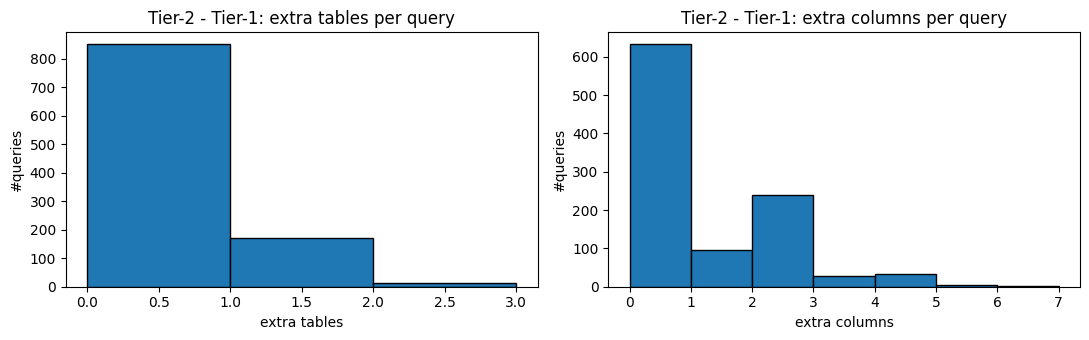

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
max_t = gap_df["extra_tables"].max()
axes[0].hist(gap_df["extra_tables"], bins=range(0, max_t + 2), edgecolor="black")
axes[0].set_title("Tier-2 - Tier-1: extra tables per query")
axes[0].set_xlabel("extra tables"); axes[0].set_ylabel("#queries")
max_c = gap_df["extra_columns"].max()
axes[1].hist(gap_df["extra_columns"], bins=range(0, max_c + 2), edgecolor="black")
axes[1].set_title("Tier-2 - Tier-1: extra columns per query")
axes[1].set_xlabel("extra columns"); axes[1].set_ylabel("#queries")
plt.tight_layout(); plt.show()

## 5. Per-hardness breakdown

Spider's canonical easy / medium / hard / extra binning (from `utils/difficulty.py`). Agreement is expected to drop as hardness rises, because harder queries lean on joins and subqueries where Tier-1's strict semantics diverge from the human annotator's reading.

In [10]:
hardness_by_qid = {ex.question_id: eval_hardness(ex.sql) for ex in dev}

hardness_rows = []
for hardness in ["easy", "medium", "hard", "extra"]:
    qids = [qid for qid, h in hardness_by_qid.items() if h == hardness]
    if not qids:
        continue
    gold_subset = {qid: taniguchi[qid] for qid in qids if qid in taniguchi}
    pred_subset = {qid: tier1[qid]      for qid in qids if qid in tier1}
    for level, key_fn in [("tables", lambda g: g.tables), ("columns", lambda g: g.columns)]:
        m = micro_metrics(gold_subset, pred_subset, key_fn)
        hardness_rows.append({"hardness": hardness, "n": len(gold_subset), "level": level, **m})

hardness_df = pd.DataFrame(hardness_rows)[["hardness", "n", "level", "precision", "recall", "f1", "srr"]]
hardness_df.round(4)

,hardness,n,level,precision,recall,f1,srr
0,easy,248,tables,0.9960,0.9727,0.9842,0.9718
1,easy,248,columns,0.9213,0.9894,0.9542,0.9879
2,medium,446,tables,0.9571,0.8590,0.9054,0.8139
3,medium,446,columns,0.8687,0.9554,0.9100,0.9148
4,hard,174,tables,0.9446,0.8920,0.9176,0.8218
5,hard,174,columns,0.7743,0.9155,0.8390,0.8793
6,extra,166,tables,0.9549,0.8017,0.8716,0.6325
7,extra,166,columns,0.7741,0.9104,0.8368,0.8494


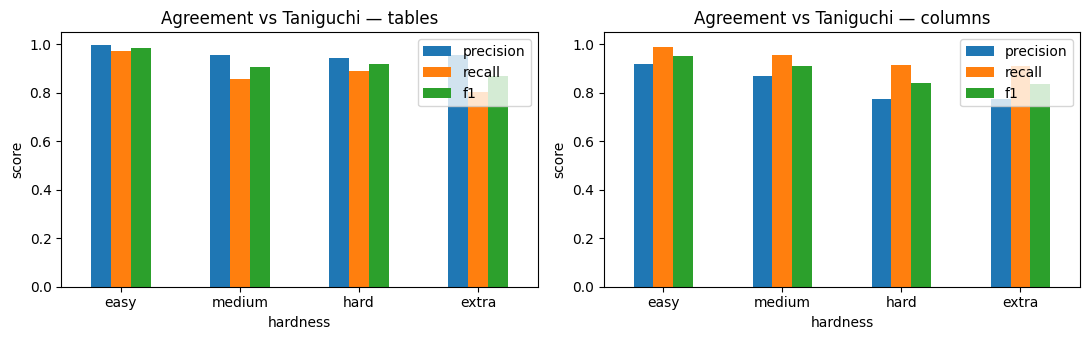

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, level in zip(axes, ["tables", "columns"]):
    sub = hardness_df[hardness_df["level"] == level].set_index("hardness")
    sub[["precision", "recall", "f1"]].reindex(["easy", "medium", "hard", "extra"]).plot(
        ax=ax, kind="bar", ylim=(0, 1.05)
    )
    ax.set_title(f"Agreement vs Taniguchi — {level}")
    ax.set_ylabel("score")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [12]:
hardness_out = Path("outputs/results/tier1_validation_by_hardness.csv")
hardness_df.round(6).to_csv(hardness_out, index=False)
print(f"wrote {hardness_out}")

wrote outputs/results/tier1_validation_by_hardness.csv


## 6. Worked examples — `concert_singer`

Three dev questions over the same database, the three gold-link sources side-by-side. This is the figure that lands in the methodology chapter — the divergence between Taniguchi Tier-1 (human, intent-driven), sqlglot Tier-1 (strict-mention), and sqlglot Tier-2 (all-SQL-used) is exactly what the thesis evaluates against.

In [13]:
# Three concert_singer dev questions chosen to span: single-table count,
# ORDER BY + LIMIT, and a nested-subquery NOT IN.
cs_questions = [
    "How many singers do we have?",
    "Show the name and the release year of the song by the youngest singer.",
    "What are the names of the stadiums without any concerts?",
]

def fmt(g):
    return f"tables={list(g.tables)}\n          columns={list(g.columns)}"

for q in cs_questions:
    matches = [ex for ex in dev if ex.question == q]
    if not matches:
        print(f"!! not found in dev: {q!r}")
        continue
    ex = matches[0]
    qid = ex.question_id
    print("=" * 88)
    print(f"qid={qid}  db={ex.db_id}")
    print(f"  Q   : {ex.question}")
    print(f"  SQL : {ex.query}")
    print(f"  Taniguchi Tier-1: {fmt(taniguchi[qid])}")
    print(f"  sqlglot   Tier-1: {fmt(tier1[qid])}")
    print(f"  sqlglot   Tier-2: {fmt(tier2[qid])}")
    print()

qid=0  db=concert_singer
  Q   : How many singers do we have?
  SQL : SELECT count(*) FROM singer
  Taniguchi Tier-1: tables=['singer']
          columns=[]
  sqlglot   Tier-1: tables=['singer']
          columns=[]
  sqlglot   Tier-2: tables=['singer']
          columns=[]

qid=6  db=concert_singer
  Q   : Show the name and the release year of the song by the youngest singer.
  SQL : SELECT song_name ,  song_release_year FROM singer ORDER BY age LIMIT 1
  Taniguchi Tier-1: tables=['singer']
          columns=[('singer', 'Name'), ('singer', 'Song_release_year')]
  sqlglot   Tier-1: tables=['singer']
          columns=[('singer', 'Age'), ('singer', 'Song_Name'), ('singer', 'Song_release_year')]
  sqlglot   Tier-2: tables=['singer']
          columns=[('singer', 'Age'), ('singer', 'Song_Name'), ('singer', 'Song_release_year')]

qid=29  db=concert_singer
  Q   : What are the names of the stadiums without any concerts?
  SQL : SELECT name FROM stadium WHERE stadium_id NOT IN (SELECT stadiu

## Takeaways

- **Canonical Tier-1 on dev** = Taniguchi. sqlglot Tier-1 is reported alongside as an automated baseline and is the only Tier-1 source on train (no human annotation exists for train; see `docs/decisions.md`).
- **Tier-2** is the recall-completeness target. Every method in the thesis is evaluated against both tiers per the scope document.
- The ~40 % of dev queries where Taniguchi and sqlglot Tier-1 disagree are a finding (intent vs structure), not a bug. The methodology chapter will analyse divergence cases; the figure in §6 is what shows the difference at a glance.